In [1]:
import numpy as np
import pandas as pd 
import torch
import torch.nn as nn 
import torch.optim as optim 
import torch.utils.data as tdata
from sklearn.preprocessing import StandardScaler
from datetime import date, datetime, timedelta 
from dateutil import relativedelta
from timeit import default_timer as timer

import warnings 
warnings.filterwarnings("ignore")

from preprocess_data import * 
from model_training import *
from test_models import *

In [7]:
import sys
import os 
pjrt = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(pjrt)

from src.load_data import load_stocks
from src.xgboost_model.xgboost_etl import *

In [8]:
# start with a basic model
start_date = "2015-11-01"
end_date = datetime.today().strftime("%Y-%m-%d")
cutoff = datetime(2025, 9, 1, 0, 0, 0)

df = load_stocks(["AAPL"], start_date, end_date, use_polars=False)
# df_full = prep_columns(df, "close").to_pandas().dropna()

feat_cols = [c for c in df.columns if c not in ["date", "ticker", "close"]]

# df_full.head()
df.head()

[*********************100%***********************]  1 of 1 completed


Field,date,ticker,close,high,low,open,volume
0,2015-11-02,AAPL,27.205873,27.246285,26.853396,27.120561,128813200
1,2015-11-03,AAPL,27.517939,27.724486,27.098108,27.118315,182076000
2,2015-11-04,AAPL,27.389969,27.798573,27.304656,27.643662,179544400
3,2015-11-05,AAPL,27.263706,27.662787,27.096860,27.473392,158210800
4,2015-11-06,AAPL,27.295265,27.464367,27.196060,27.306539,132169200


In [9]:
# for some feature engineering, these guys (https://arxiv.org/html/2501.17366v1#S3) used:
# 3.1 Data Sources and Features

# The dataset used in this study encompasses daily values for the S&P 500 (SPX) over the period of October 2013 to September 2024. The historical SPX data include:

# • 50 and 200-day Moving Averages (MOV_AVG_50/200D)
# • 14-day Relative Strength Index (RSI_14D)
# • Open and Closing Prices (PX_OPEN/CLOSE)
# • High and Low Prices (PX_HIGH/LOW)
# • Daily Price High-Low Difference (PX_HIGH_LOW_DIFFERENCE)
# • Daily Volume (PX_VOLUME)
# • 30-day Volatility (VOLATILITY_30D)
# • Beta (BETA_ADJ_OVERRIDABLE)

In [10]:
# even worth doing lstm
lookback = 30
train_prop = 0.7

values = df[feat_cols + ["close"]].values.astype("float32")

X_list, y_list = [], []
for i in range(lookback, len(values)):
    X_list.append(values[i-lookback:i, :-1])
    y_list.append(values[i, -1])

y_all = np.array(y_list)
n_train = int(len(y_all) * train_prop)

y_train_np = y_all[:n_train]
y_test_np = y_all[n_train:]

y_pred_naive = np.roll(y_all, 1)[n_train:]
y_true = y_test_np
naive_rmse = np.sqrt(np.mean((y_pred_naive - y_true) ** 2))
print(f"naive 1-step RMSE (y_t = y_(t-1)): {naive_rmse:.5f}")

naive 1-step RMSE (y_t = y_(t-1)): 3.25958


In [18]:
df_scaled, scaler = scale_features(df, feat_cols)
X_train, X_test, y_train, y_test = make_lstm_sequences(df_scaled, feat_cols, "close", lookback=90)

print(X_train.shape, y_train.shape, X_train.dtype, y_train.dtype)
print(X_test.shape, y_test.shape, X_test.dtype, y_test.dtype)

torch.Size([1709, 90, 4]) torch.Size([1709]) torch.float32 torch.float32
torch.Size([733, 90, 4]) torch.Size([733]) torch.float32 torch.float32


In [19]:
input_size = X_train.shape[-1]

model1 = LSTMStockForecaster(input_units=input_size)
model2 = LSTMBiDirStockForecaster(input_units=input_size)
model3 = AttentiveLSTMStockForecaster(input_units=input_size)
model4 = GRUStockForecaster(input_units=input_size)

In [20]:
loss_fn = nn.MSELoss()

train_dataloader = tdata.DataLoader(
    tdata.TensorDataset(X_train, y_train), shuffle=True, batch_size=8
)
test_dataloader = tdata.DataLoader(
    tdata.TensorDataset(X_test, y_test), shuffle=False, batch_size=8
)

epochs = 50

In [21]:
res1 = train_model(
    model=model1,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model1.parameters(), lr=0.001),
    epochs=epochs
)

epoch: 0
 train loss: 70.32684
 test_loss: 131.58012
 run time: 1.4146586249989923


epoch: 1
 train loss: 31.51728
 test_loss: 58.85648
 run time: 1.331627000006847


epoch: 2
 train loss: 12.44154
 test_loss: 40.40435
 run time: 1.3409608750080224


epoch: 3
 train loss: 12.10818
 test_loss: 34.82793
 run time: 1.3412687910022214


epoch: 4
 train loss: 12.27724
 test_loss: 31.87829
 run time: 1.3376520000165328


epoch: 5
 train loss: 11.89441
 test_loss: 34.26715
 run time: 1.3357615410059225


epoch: 6
 train loss: 12.15671
 test_loss: 30.97788
 run time: 1.3301250000076834


epoch: 7
 train loss: 12.01335
 test_loss: 30.22032
 run time: 1.335202834015945


epoch: 8
 train loss: 11.54280
 test_loss: 26.34468
 run time: 1.4294094579818193


epoch: 9
 train loss: 11.76008
 test_loss: 24.85080
 run time: 1.6650277909939177


epoch: 10
 train loss: 12.17855
 test_loss: 23.39225
 run time: 1.3306562079815194


epoch: 11
 train loss: 12.02139
 test_loss: 23.54625
 run time: 1.3328800000

In [22]:
res2 = train_model(
    model=model2,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model2.parameters(), lr=0.001),
    epochs=epochs
)

epoch: 0
 train loss: 80.55649
 test_loss: 168.92064
 run time: 2.783095416991273


epoch: 1
 train loss: 58.33568
 test_loss: 138.93477
 run time: 2.659812416008208


epoch: 2
 train loss: 40.88760
 test_loss: 115.40812
 run time: 2.6717747499933466


epoch: 3
 train loss: 27.29681
 test_loss: 93.66021
 run time: 2.696833791997051


epoch: 4
 train loss: 16.58010
 test_loss: 74.47848
 run time: 2.7519418329757173


epoch: 5
 train loss: 10.29564
 test_loss: 61.45758
 run time: 2.734758332982892


epoch: 6
 train loss: 7.05386
 test_loss: 54.94636
 run time: 2.813648415991338


epoch: 7
 train loss: 6.10968
 test_loss: 47.38509
 run time: 2.7548570829967503


epoch: 8
 train loss: 4.48542
 test_loss: 44.90379
 run time: 2.724712750001345


epoch: 9
 train loss: 3.87078
 test_loss: 40.24197
 run time: 2.666924791992642


epoch: 10
 train loss: 3.51347
 test_loss: 37.22401
 run time: 2.8255115829815622


epoch: 11
 train loss: 2.73384
 test_loss: 35.56239
 run time: 2.6778678330010734




In [23]:
res3 = train_model(
    model=model3,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model3.parameters(), lr=0.001),
    epochs=epochs
)

epoch: 0
 train loss: 80.92686
 test_loss: 179.89876
 run time: 1.4655907500127796


epoch: 1
 train loss: 68.27090
 test_loss: 166.14302
 run time: 1.4375372499926016


epoch: 2
 train loss: 59.93143
 test_loss: 154.37244
 run time: 1.434187209000811


epoch: 3
 train loss: 52.69717
 test_loss: 143.11794
 run time: 1.4380664580094162


epoch: 4
 train loss: 45.39114
 test_loss: 130.83565
 run time: 1.4343236250279006


epoch: 5
 train loss: 38.51835
 test_loss: 118.70129
 run time: 1.4409218750079162


epoch: 6
 train loss: 32.00402
 test_loss: 106.78695
 run time: 1.4582477920048404


epoch: 7
 train loss: 26.02958
 test_loss: 95.63952
 run time: 1.4513788750045933


epoch: 8
 train loss: 21.22247
 test_loss: 85.61112
 run time: 1.4639469170069788


epoch: 9
 train loss: 17.21687
 test_loss: 76.24680
 run time: 1.432698958000401


epoch: 10
 train loss: 13.82461
 test_loss: 68.25564
 run time: 1.4326941659965087


epoch: 11
 train loss: 11.75736
 test_loss: 62.34209
 run time: 1.4319

In [24]:
res4 = train_model(
    model=model4,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    loss_fn=loss_fn,
    optimizer=optim.Adam(model4.parameters(), lr=0.001),
    epochs=epochs
)

epoch: 0
 train loss: 81.47131
 test_loss: 181.54807
 run time: 1.4512806670099963


epoch: 1
 train loss: 69.54175
 test_loss: 167.95131
 run time: 1.3881414580100682


epoch: 2
 train loss: 61.13785
 test_loss: 155.94327
 run time: 1.4089687920059077


epoch: 3
 train loss: 54.75339
 test_loss: 146.08774
 run time: 1.281205958017381


epoch: 4
 train loss: 51.34872
 test_loss: 139.02357
 run time: 1.2992169170174748


epoch: 5
 train loss: 46.89464
 test_loss: 129.69688
 run time: 1.2874974590085912


epoch: 6
 train loss: 37.01348
 test_loss: 116.21655
 run time: 1.286536250001518


epoch: 7
 train loss: 29.63382
 test_loss: 103.08220
 run time: 1.2855438749829773


epoch: 8
 train loss: 22.75764
 test_loss: 90.47573
 run time: 1.2853438750025816


epoch: 9
 train loss: 16.33662
 test_loss: 79.05069
 run time: 1.2897825420077424


epoch: 10
 train loss: 12.03595
 test_loss: 69.77465
 run time: 1.3081659589952324


epoch: 11
 train loss: 8.99666
 test_loss: 62.62931
 run time: 1.5021

In [41]:
def make_df_from_res(res):
    return pd.DataFrame(
    {
        "epoch": list(range(len(res["train_loss"]))),
        "train_loss": [t.item() for t in res["train_loss"]],
        "test_loss": [t.item() for t in res["test_loss"]]
    }
)

In [42]:
df_res1 = make_df_from_res(res1)
df_res2 = make_df_from_res(res2)
df_res3 = make_df_from_res(res3)
df_res4 = make_df_from_res(res4)

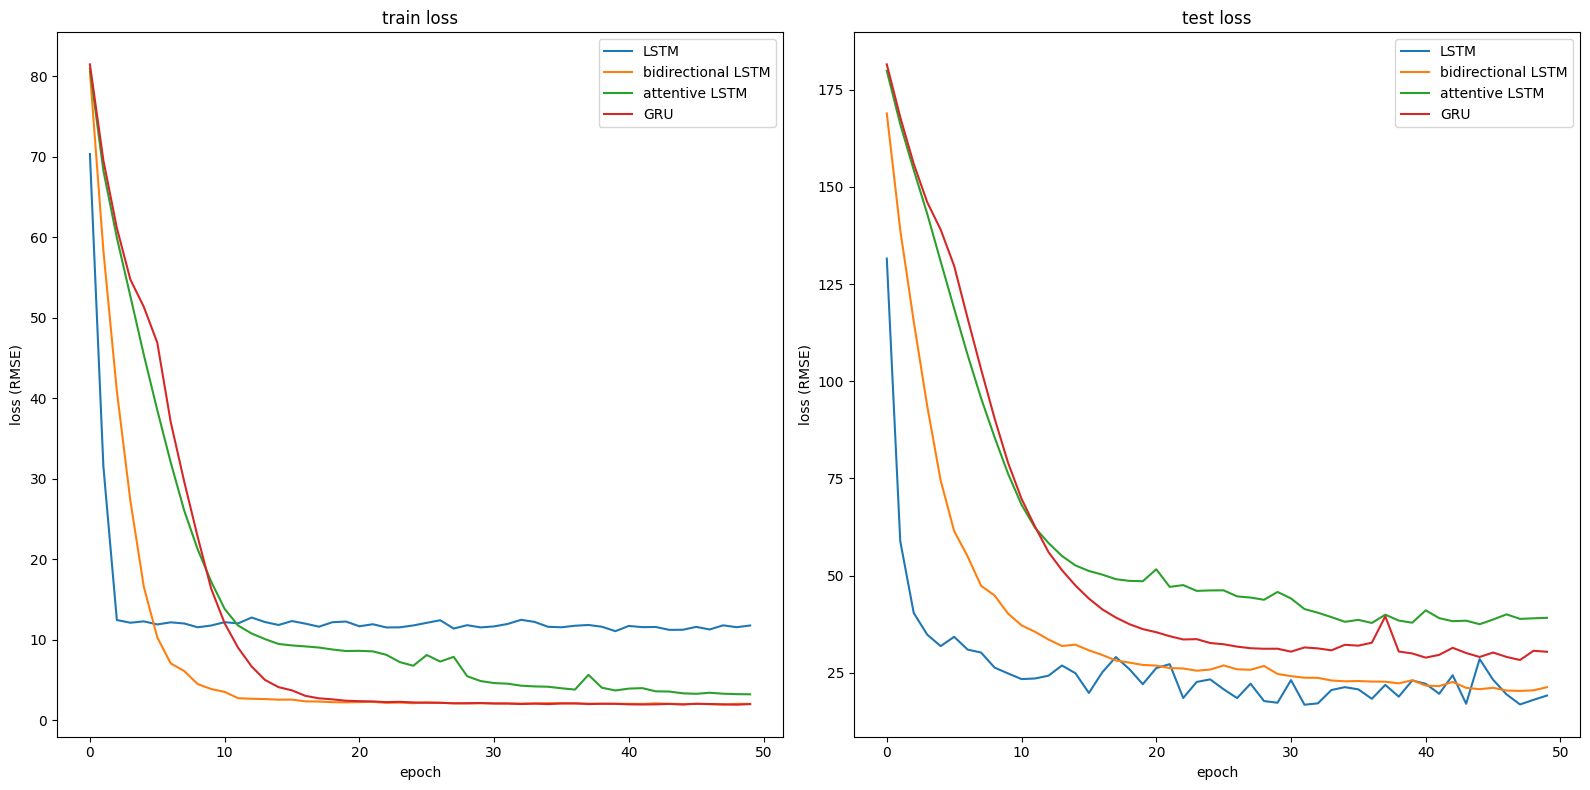

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 8));

plt.subplot(1, 2, 1);
plt.plot(df_res1["epoch"], df_res1["train_loss"], label="LSTM");
plt.plot(df_res2["epoch"], df_res2["train_loss"], label="bidirectional LSTM");
plt.plot(df_res3["epoch"], df_res3["train_loss"], label="attentive LSTM");
plt.plot(df_res4["epoch"], df_res4["train_loss"], label="GRU");

plt.legend();
plt.xlabel("epoch");
plt.ylabel("loss (RMSE)");
plt.title("train loss");


plt.subplot(1, 2, 2);
plt.plot(df_res1["epoch"], df_res1["test_loss"], label="LSTM");
plt.plot(df_res2["epoch"], df_res2["test_loss"], label="bidirectional LSTM");
plt.plot(df_res3["epoch"], df_res3["test_loss"], label="attentive LSTM");
plt.plot(df_res4["epoch"], df_res4["test_loss"], label="GRU");

plt.legend();
plt.xlabel("epoch");
plt.ylabel("loss (RMSE)");
plt.title("test loss");


plt.tight_layout();